In [7]:
MODEL_SAVE_PATH = "/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v5.1"
FILE_PATH = "~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_17_Training.gpkg"
BASE_PATH = "~/Documents/ml-prep/ML-PREP-2025/learn/data"

# Scripts to Train the PINN Model
* This version of the script integrates the pore pressure term in the Factor of Safety(FOS)
* Uses the latest geopackage data during training and validation of the trained PINN Model



In [8]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Import necessary packages and modules
import geopandas as gpd 
from py_files.data import preprocessing
from py_files.train_rainfall import train_model_rainfall
from py_files.GallenModel_v1 import CohesionLayer

In [9]:
df = gpd.read_file(f"{BASE_PATH}/SU_17_training_v3_contri.gpkg")
df.columns, df['LITHO'].head(), df['LITHODESC'].head(), df['Geomorphology'].unique(), df['LITHO'].unique(), df['type'].unique(), df['ContributingFactor_mean'].describe()

(Index(['DN', 'BD_mean', 'Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean',
        'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean',
        'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean',
        'PGA2_max', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min',
        'Soil Type', 'BUK_mean', 'landslide', 'landslide_probability',
        'landslide_preds', 'confusion', 'sus_pinn_landslide',
        'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction',
        'descriptio', 'type', 'Landslide1', 'LITHO', 'LITHODESC', 'Lithology',
        'Geomorphology', 'LITHO_2', 'LITHODESC_2', 'value',
        'ContributingFactor_mean', 'geometry'],
       dtype='object'),
 0    Marine clastics, pyroclastics
 1    Marine clastics, pyroclastics
 2    Marine clastics, pyroclastics
 3    Marine clastics, pyroclastics
 4    Marine clastics, pyroclastics
 Name: LITHO, dtype: object,
 0    Marine clastics overlain by pyroclastics and t...
 1    Mari

In [4]:
# zonal = gpd.read_file(f"{BASE_PATH}/Clay_north_cotabato_zonal.gpkg")
# zonal.head()

In [5]:


df, columns, numeric_cols = preprocessing(df, columns_drop=['Landslide1', 'descriptio', 'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction', 'sus_pinn_landslide', 'confusion', 'landslide_preds', 'landslide_probability', 'Lithology', 'LITHO', 'Geomorphology', 'LITHODESC'])
df, columns, numeric_cols

(           DN     BD_mean   Clay_mean   Sand_mean   Silt_mean  NDVI_mean  \
 0      334408   79.858468  360.346280  340.681485  298.954953   0.665530   
 1      334743   79.968610  360.539905  341.044167  298.269993   0.515360   
 2      334964   80.785985  358.393445  340.194179  301.392539   0.475615   
 3      340699   95.246127  366.153165  332.831341  301.015494   0.787397   
 4      340261   95.472952  360.236476  338.236476  301.527048   0.790155   
 ...       ...         ...         ...         ...         ...        ...   
 57886  368656  114.905016  309.625697  342.500796  347.309237   0.787355   
 57887  368684  117.700647  310.552072  343.087297  346.360631   0.793820   
 57888  367913  118.624019  319.928663  337.371128  343.024020   0.804874   
 57889  367829  115.711382  314.179934  329.151580  356.848420   0.821656   
 57890  367292  127.708907  314.459428  332.778282  352.762290   0.723508   
 
        Est_mean  Nrt_mean  HorCurv_mean  VertCurv_mean  ...  PGA2_max  \


2026-03-05 14:26:25.395565: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-05 14:26:25.572306: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-05 14:26:25.910196: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-05 14:26:26.579855: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-05 14:26:27.910177: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
Epoch 1/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6972 - auc: 0.6635 - binary_io_u: 0.4180 - loss: 1.2448 - val_accuracy: 0.6941 - val_auc: 0.7015 - val_binary_io_u: 0.4218 - val_loss: 0.9256
Epoch 2/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7304 - auc: 0.6449 - binary_io_u: 0.4322 - loss: 1.1328 - val_accuracy: 0.7407 - val_auc: 0.6219 - val_binary_io_u: 0.4307 - val_loss: 0.8069
Epoch 3/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7505 - auc: 0.6331 - binary_io_u: 0.4407 - loss: 1.0581 - val_accuracy: 0.7656 - val_auc: 0.6003 - val_binary_io_u: 0.4400 - val_loss: 0.7570
Epoch 4/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7687 - auc: 0.6085 - binary_io_u: 0.4423 - loss: 0.9929 - val_accuracy: 0.7869 - val_auc: 0.5923 - val_binary_io_u: 0.4479 - val_loss: 0.7181
Epoch 5/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7932 - auc: 0.6054 - binary_io_u: 0.4528 - loss: 0.9272 - val_accuracy: 0.8049 

2026-03-05 14:27:36.899163: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
Epoch 1/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6449 - auc_1: 0.7214 - binary_io_u_1: 0.3935 - loss: 1.3950 - val_accuracy: 0.6145 - val_auc_1: 0.7188 - val_binary_io_u_1: 0.3750 - val_loss: 1.0577
Epoch 2/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6774 - auc_1: 0.7246 - binary_io_u_1: 0.4161 - loss: 1.2955 - val_accuracy: 0.6806 - val_auc_1: 0.7272 - val_binary_io_u_1: 0.4186 - val_loss: 0.9253
Epoch 3/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6963 - auc_1: 0.7156 - binary_io_u_1: 0.4240 - loss: 1.2224 - val_accuracy: 0.7149 - val_auc_1: 0.7191 - val_binary_io_u_1: 0.4372 - val_loss: 0.8552
Epoch 4/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7294 - auc_1: 0.7015 - binary_io_u_1: 0.4393 - loss: 1.1207 - val_accuracy: 0.7532 - val_auc_1: 0.7027 - val_binary_io_u_1: 0.4571 - val_loss: 0.7792
Epoch 5/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7570 - auc_1: 0.6928 - binary_io_u_1: 0.4537 - 

2026-03-05 14:29:56.015490: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
Epoch 1/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5912 - auc_3: 0.6988 - binary_io_u_3: 0.3600 - loss: 1.5544 - val_accuracy: 0.6445 - val_auc_3: 0.7281 - val_binary_io_u_3: 0.3951 - val_loss: 1.0034
Epoch 2/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6191 - auc_3: 0.6918 - binary_io_u_3: 0.3756 - loss: 1.4675 - val_accuracy: 0.6778 - val_auc_3: 0.7143 - val_binary_io_u_3: 0.4126 - val_loss: 0.9367
Epoch 3/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6564 - auc_3: 0.7007 - binary_io_u_3: 0.3987 - loss: 1.3354 - val_accuracy: 0.6940 - val_auc_3: 0.7132 - val_binary_io_u_3: 0.4224 - val_loss: 0.8913
Epoch 4/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6938 - auc_3: 0.7049 - binary_io_u_3: 0.4217 - loss: 1.2174 - val_accuracy: 0.7317 - val_auc_3: 0.7001 - val_binary_io_u_3: 0.4428 - val_loss: 0.8076
Epoch 5/200
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7251 - auc_3: 0.6897 - binary_io_u_3: 0.4388 - 

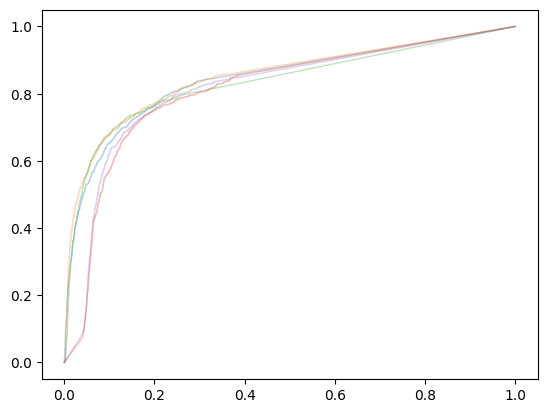

In [6]:
train_model_rainfall(df, numeric_cols, ['type'], columns, "PGA1_max", MODEL_SAVE_PATH)

In [8]:
from tensorflow.keras.models import load_model
from py_files.GallenModel_v1 import InternalFrictionLayer, NewmarkActivation
from py_files.LandslideRainfall import LandslideRainFall
model = load_model(f"{MODEL_SAVE_PATH}/fold-1-model-0.keras", custom_objects={
    "CohesionLayer":CohesionLayer,
    "NewmarkActivation":NewmarkActivation,
    "InternalFrictionLayer": InternalFrictionLayer
})

In [9]:
from py_files.data import dataframe_to_dataset


validation_df = gpd.read_file(FILE_PATH)

#:((
column_map = {
    "Geomorph":"Geomorphology",
    "LITHODESC_2":"LITHODESC",
    "Soil Type":"type"
}
validation_df, columns, numeric_cols = preprocessing(validation_df, columns_drop=['Landslide1', 'sus_pinn_ground truth', 'descriptio', 'ds', 'cohesion', 'internal_friction', 'sus_pinn_landslide', 'confusion', 'landslide_preds', 'landslide_probability', 'Lithology', 'LITHO', 'Geomorphology', 'LITHODESC'])
validation_ds = dataframe_to_dataset(validation_df[columns], shuffle=False, batch_size=128)

/Users/giogonzales/Documents/ml-prep/mlprep/venv/lib/python3.12/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'SU_17_Training.gpkg': 'zonal_statistics' (default), 'joined_layer'. Specify layer parameter to avoid this warning.
  result = read_func(


445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 891us/step
445/445 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step
445/445 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step


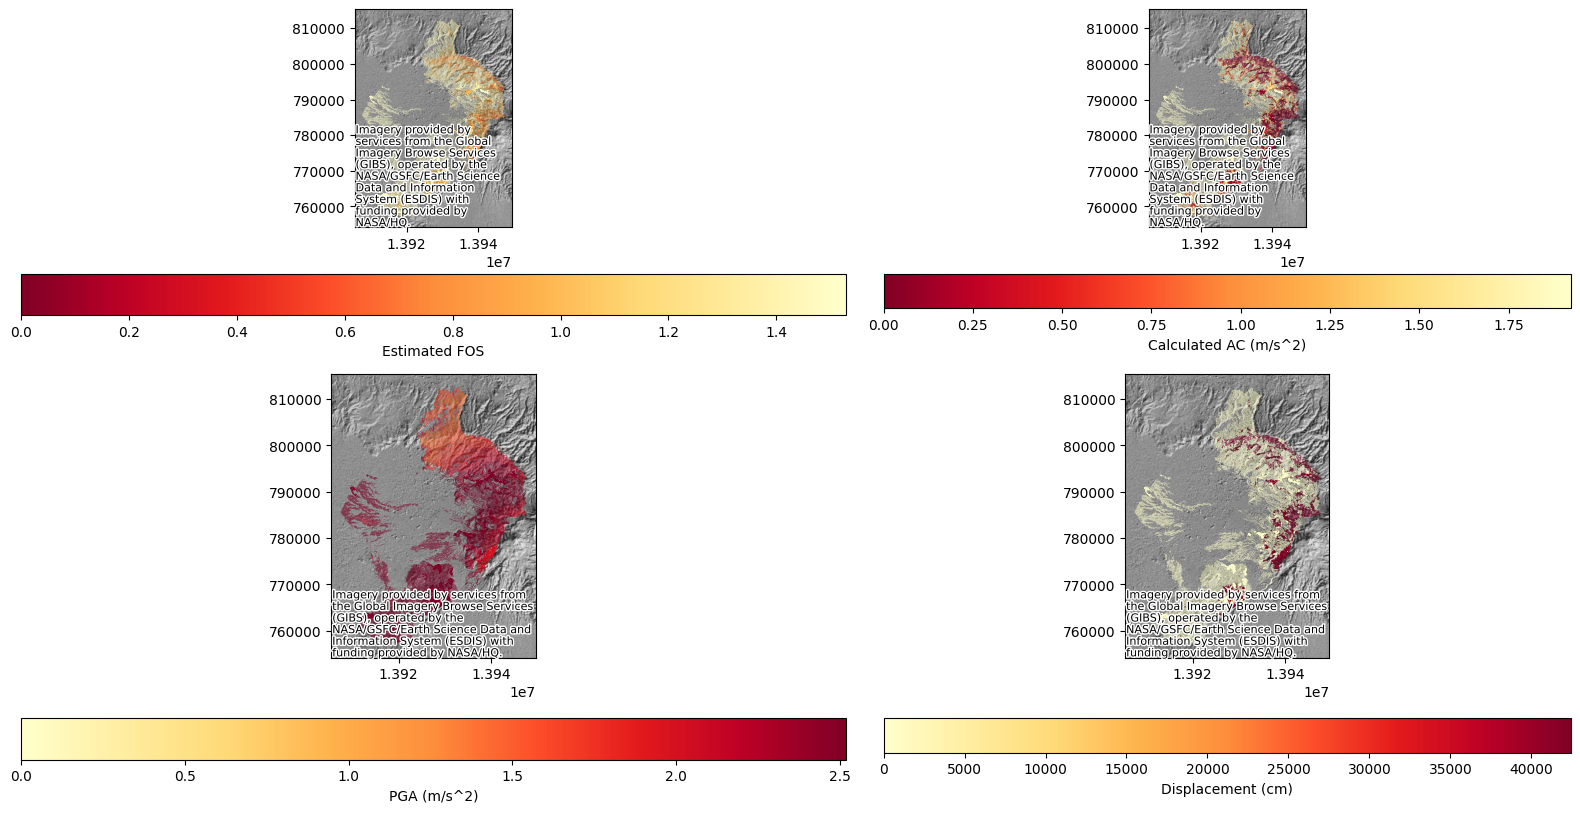

In [10]:
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib import pyplot as plt
import numpy as np
import tensorflow as tf
import contextily as cx
fig = plt.figure(figsize=(20, 10))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.2, 1],   # columns
    height_ratios=[1, 1.3],  # rows
    wspace=0.05,
    hspace=0.15
)

ax = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
])

df_wm = validation_df.to_crs(epsg=3857)
fos_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("fos_layer").output)
predicted_fos = fos_model.predict(validation_ds)
df_wm['estimated_fos'] = predicted_fos

norm = mcolors.Normalize(vmin=0, vmax=df_wm['estimated_fos'].median())
df_wm.plot(column="estimated_fos", legend=True, alpha=0.7, norm=norm, ax=ax[0][0], cmap='YlOrRd_r', legend_kwds={"label": "Estimated FOS", "orientation": "horizontal"})
cx.add_basemap(ax=ax[0][0],source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')

ac_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer('critical_acceleration').output)
predicted_acceleration = ac_model.predict(validation_ds)

df_wm['slope_radians'] = df_wm['Slope_mean'] * 0.017453292519943295
df_wm['calculated_ac'] = (df_wm['estimated_fos'] - 1) * 9.81 * np.sin(df_wm['slope_radians'])
df_wm['estimated_ac'] = predicted_acceleration[0]

# df_wm['calculated_ac'] = df_wm['calculated_ac'] / 9.81

ac_norm = mcolors.Normalize(vmin=0, vmax=df_wm['calculated_ac'].median())

df_wm.plot(column="estimated_ac", legend=True, alpha=0.7, norm=ac_norm, ax=ax[0][1], cmap='YlOrRd_r', legend_kwds={"label": "Calculated AC (m/s^2)", "orientation": "horizontal"})
cx.add_basemap(ax=ax[0][1],source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')

# displacement_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("modified_fos_displacement").output)
# predicted_ds = displacement_model.predict(validation_ds)
# df_wm['estimated_displacement'] = predicted_ds[0]

df_wm['PGA1_max'] *= 9.81
ac_norm = mcolors.Normalize(vmin=0, vmax=df_wm['PGA1_max'].median())
df_wm.plot(column="PGA1_max", legend=True, alpha=0.7, norm=ac_norm, ax=ax[1][0], cmap="YlOrRd", legend_kwds={"label": "PGA (m/s^2)", "orientation": "horizontal"})
cx.add_basemap(ax=ax[1][0],source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')

df_wm['acpg'] = predicted_acceleration[1]

displacement_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("displacement_layer").output)
predicted_displacement = displacement_model.predict(validation_ds)
df_wm['estimated_ds'] = predicted_displacement

ac_norm = mcolors.Normalize(vmin=0, vmax=df_wm['estimated_ds'].quantile(0.95))
df_wm.plot(column='estimated_ds', legend=True, alpha=0.7, ax=ax[1][1], cmap="YlOrRd", norm=ac_norm,  legend_kwds={"label": "Displacement (cm)", "orientation": "horizontal"})
cx.add_basemap(ax=ax[1][1],source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief',) 


<Axes: xlabel='acpg', ylabel='estimated_ds'>

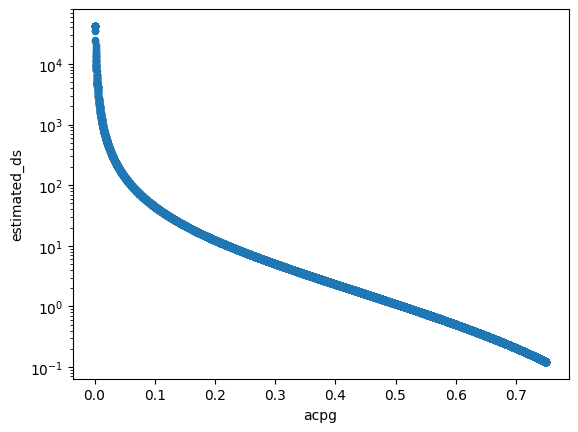

In [11]:
df_wm.plot.scatter(x="acpg", y='estimated_ds', logy=True)

In [12]:
"""
    Retrieve the FOS, PGA, AC in the areas where Displacement is so big
"""
quantile_95 = df_wm['estimated_ds'].quantile(0.95)

above_95_df = df_wm[df_wm['estimated_ds'] >= quantile_95]
above_95_df

,DN,BD_mean,Clay_mean,Sand_mean,Silt_mean,NDVI_mean,Est_mean,Nrt_mean,HorCurv_mean,VertCurv_mean,...,BUK_mean,landslide,type,geometry,estimated_fos,slope_radians,calculated_ac,estimated_ac,acpg,estimated_ds
2,334964,80.785985,358.393445,340.194179,301.392539,0.475615,-0.388284,0.865236,-0.006900,0.002413,...,10.476539,1,Undifferentiated,"MULTIPOLYGON (((13939427.509 778921.724, 13939...",0.743130,0.681856,-1.588126,0.0,0.001,42446.921875
3,340699,95.246127,366.153165,332.831341,301.015494,0.787397,0.274677,-0.559830,0.001612,-0.000406,...,10.921050,1,Undifferentiated,"MULTIPOLYGON (((13939682.806 776431.811, 13939...",0.709347,0.706553,-1.851110,0.0,0.001,42446.921875
4,340261,95.472952,360.236476,338.236476,301.527048,0.790155,0.545462,-0.813949,0.003602,0.000275,...,10.907936,1,Undifferentiated,"MULTIPOLYGON (((13939703.534 776558.427, 13939...",0.665035,0.739396,-2.214249,0.0,0.001,42446.921875
5,340305,95.082654,360.041327,338.041327,301.917346,0.802328,0.540705,-0.793562,0.003914,-0.000320,...,10.906600,1,Undifferentiated,"MULTIPOLYGON (((13939733.603 776527.874, 13939...",0.618186,0.776116,-2.623839,0.0,0.001,42446.921875
6,314782,98.789986,366.931558,352.812286,279.904817,0.789155,0.528948,0.827227,0.001475,0.000541,...,10.940238,1,Undifferentiated,"MULTIPOLYGON (((13944820.839 786418.375, 13944...",0.767524,0.673192,-1.421916,0.0,0.001,42446.921875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57858,366057,126.000000,312.000000,357.000000,332.000000,0.839316,0.837314,0.546517,-0.006680,0.000531,...,11.077977,0,Sandy Clay Loam,"MULTIPOLYGON (((13915477.042 761770.324, 13915...",0.929257,0.580084,-0.380373,0.0,0.001,42446.921875
57859,366058,126.000000,312.000000,357.000000,332.000000,0.856783,0.859197,0.511552,0.001665,-0.005316,...,11.078959,0,Sandy Clay Loam,"MULTIPOLYGON (((13915482.077 761770.303, 13915...",0.877112,0.615478,-0.696013,0.0,0.001,42446.921875
57861,366074,126.000000,312.000000,357.000000,332.000000,0.875227,0.863626,0.504099,0.001379,-0.006591,...,11.078959,0,Sandy Clay Loam,"MULTIPOLYGON (((13915487.09 761765.214, 139154...",0.927967,0.596247,-0.396810,0.0,0.001,42446.921875
57863,365479,126.000000,312.000000,353.000000,335.000000,0.780748,-0.854103,-0.510864,0.039636,0.004062,...,11.100241,0,Sandy Clay Loam,"MULTIPOLYGON (((13915548.897 762104.504, 13915...",0.895742,0.601110,-0.578436,0.0,0.001,42446.921875


445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step


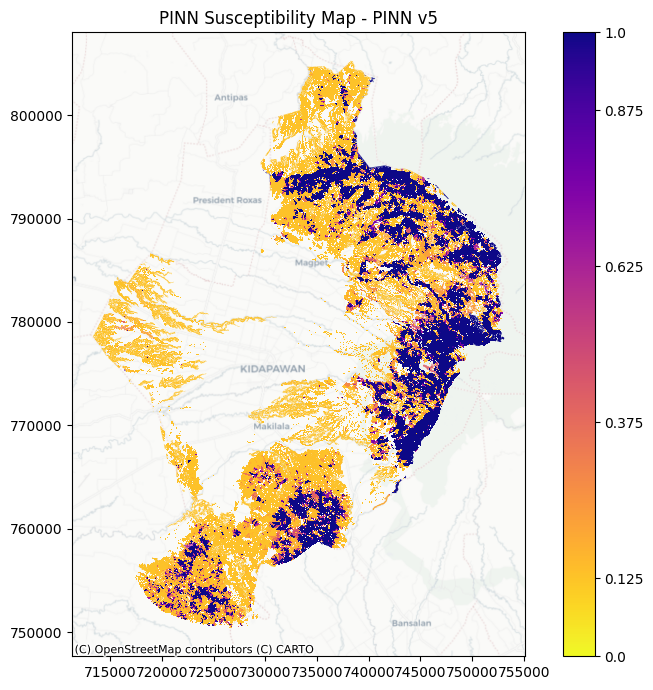

In [13]:
from py_files.metrics import plot_susceptibility_map

susceptibility_prediction = model.predict(validation_ds)
plot_susceptibility_map(validation_df, susceptibility_prediction, "PINN v5")

In [ ]:
#Extract Geotechnical estimation of the model
df_wm = validation_df.to_crs(epsg=3857)
cohesion_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("cohesion_clip").output)
predicted_cohesion = cohesion_model.predict(validation_ds)
df_wm['estimated_cohesion'] = predicted_cohesion

ax = df_wm.plot(column="estimated_cohesion", legend=True, figsize=(10, 10), alpha=0.7)
cx.add_basemap(ax,source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')
print(f"Predicted cohesion length: {len(predicted_cohesion)}")
df_wm['estimated_cohesion'].min(), df_wm['estimated_cohesion'].max()


In [ ]:
#Extract Geotechnical estimation of the model
df_wm = validation_df.to_crs(epsg=3857)
ifi_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("ifi_clip").output)
predicted_ifi = ifi_model.predict(validation_ds)
df_wm['estimated_ifi'] = predicted_ifi

ax = df_wm.plot(column="estimated_ifi", legend=True, figsize=(10, 10), alpha=0.7)
cx.add_basemap(ax,source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')
print(f"Predicted M length: {len(predicted_cohesion)}")
df_wm['estimated_ifi'].min(), df_wm['estimated_ifi'].max()


In [ ]:
#Extract Geotechnical estimation of the model
df_wm = validation_df.to_crs(epsg=3857)
m_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("m_clip").output)
predicted_m = m_model.predict(validation_ds)
df_wm['estimated_m'] = predicted_m

ax = df_wm.plot(column="estimated_m", legend=True, figsize=(10, 10), alpha=0.7)
cx.add_basemap(ax,source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')
print(f"Predicted M length: {len(predicted_cohesion)}")
df_wm['estimated_m'].min(), df_wm['estimated_m'].max(), df_wm['estimated_m'].value_counts()


In [ ]:
fos_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("fos_layer").output)
predicted_fos = fos_model.predict(validation_ds)
df_wm['estimated_fos'] = predicted_fos

norm = mcolors.Normalize(vmin=0, vmax=df_wm['estimated_fos'].median())
ax = df_wm.plot(column="estimated_fos", legend=True, alpha=0.7, norm=norm, cmap='YlOrRd_r', legend_kwds={"label": "Estimated FOS", "orientation": "horizontal"}, figsize=(10, 10))
cx.add_basemap(ax=ax, source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')

In [ ]:
displacement_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("displacement_layer").output)
predicted_displacement = displacement_model.predict(validation_ds)
df_wm['estimated_ds'] = predicted_displacement


norm = mcolors.Normalize(vmin=0, vmax=df_wm['estimated_ds'].quantile(.95))
ax = df_wm.plot(column="estimated_ds", legend=True, alpha=0.7, norm=norm, cmap='YlOrRd', legend_kwds={"label": "Estimated FOS", "orientation": "horizontal"}, figsize=(10, 10))
cx.add_basemap(ax=ax, source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')